In [2]:
import pandas as pd
import numpy as np

# Inspection

In [3]:
raw_data = pd.read_csv("../01_data/raw_full.csv")

display(raw_data.head(5))
raw_data.info()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


In [4]:
for col in raw_data.select_dtypes(include="float64").columns:
    invalid = raw_data.loc[raw_data[col] % 1 != 0, col]
    print(f"{col}: {len(invalid)} non-integer values")
    if len(invalid) > 0:
        display(invalid.head())

Region_Code: 0 non-integer values
Annual_Premium: 0 non-integer values
Policy_Sales_Channel: 0 non-integer values


In [5]:
df = raw_data.copy()

# Drop id column
df = df.drop(columns="id")

# Convert float columns containing only whole numbers to integers
float_cols = df.select_dtypes(include="float64").columns
raw_data[float_cols] = df[float_cols].astype(int)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                381109 non-null  str    
 1   Age                   381109 non-null  int64  
 2   Driving_License       381109 non-null  int64  
 3   Region_Code           381109 non-null  float64
 4   Previously_Insured    381109 non-null  int64  
 5   Vehicle_Age           381109 non-null  str    
 6   Vehicle_Damage        381109 non-null  str    
 7   Annual_Premium        381109 non-null  float64
 8   Policy_Sales_Channel  381109 non-null  float64
 9   Vintage               381109 non-null  int64  
 10  Response              381109 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 32.0 MB


In [28]:
len(df['Policy_Sales_Channel'].unique())
#len(df['Region_Code'].value_counts())

155

In [7]:
# Identify duplicate rows after removing the unique identifier
duplicate_rows = df[df.duplicated(keep=False)]

# Calculate summary statistics
num_duplicate_rows = len(duplicate_rows)
num_duplicate_pairs = duplicate_rows.groupby(df.columns.tolist()).ngroups
duplicate_percentage = (num_duplicate_rows / len(df)) * 100

print(f"Duplicate rows identified: {num_duplicate_rows}")
print(f"Duplicate pairs identified: {num_duplicate_pairs}")
print(f"Percentage of dataset: {duplicate_percentage:.3f}%")

print("\nFrequency of duplicate group sizes:")
display(duplicate_rows.groupby(df.columns.tolist()).size().value_counts())

print("\nResponse distribution among duplicate rows:")
display(duplicate_rows["Response"].value_counts())

# Measure separation between duplicate pairs
pairs = (
    duplicate_rows
    .reset_index()
    .groupby(df.columns.tolist())["index"]
    .apply(list)
)

pair_distances = pairs.apply(lambda x: abs(x[1] - x[0]))

print("\nDistance (in rows) between members of each duplicate pair:")
display(pair_distances.describe())

Duplicate rows identified: 538
Duplicate pairs identified: 269
Percentage of dataset: 0.141%

Frequency of duplicate group sizes:


2    269
Name: count, dtype: int64


Response distribution among duplicate rows:


Response
0    488
1     50
Name: count, dtype: int64


Distance (in rows) between members of each duplicate pair:


count       269.000000
mean     123530.910781
std       92509.077228
min         558.000000
25%       44617.000000
50%      106732.000000
75%      185897.000000
max      353417.000000
Name: index, dtype: float64

After removing the unique identifier (id), 269 duplicate customer profiles (538 observations) were identified, representing approximately 0.14% of the dataset. Further investigation showed that duplicate pairs included both response classes and were separated by widely varying distances within the dataset (minimum separation = 558 rows; median = 106,732 rows; maximum = 353,417 rows). Because the duplicates were dispersed throughout the dataset rather than occurring in contiguous blocks or at regular intervals, they were considered likely to represent distinct customers with identical recorded characteristics rather than data generation or import errors. Therefore, the duplicate observations were retained.

In [8]:
df.describe().round(2)

,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.00,381109.00,381109.00,381109.00,381109.00,381109.00,381109.00,381109.00
mean,38.82,1.00,26.39,0.46,30564.39,112.03,154.35,0.12
std,15.51,0.05,13.23,0.50,17213.16,54.20,83.67,0.33
min,20.00,0.00,0.00,0.00,2630.00,1.00,10.00,0.00
25%,25.00,1.00,15.00,0.00,24405.00,29.00,82.00,0.00
50%,36.00,1.00,28.00,0.00,31669.00,133.00,154.00,0.00
75%,49.00,1.00,35.00,1.00,39400.00,152.00,227.00,0.00
max,85.00,1.00,52.00,1.00,540165.00,163.00,299.00,1.00


In [9]:
for col in df.select_dtypes(include="str").columns:
    print(f"\n")
    print(df[col].value_counts())

Gender
Male      206089
Female    175020
Name: count, dtype: int64


Vehicle_Age
1-2 Year     200316
< 1 Year     164786
> 2 Years     16007
Name: count, dtype: int64


Vehicle_Damage
Yes    192413
No     188696
Name: count, dtype: int64


# EDA

/var/folders/bb/9wscb13j3ml205njxw9_qtmh0000gn/T/ipykernel_12907/3934928395.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[col], vert=True)


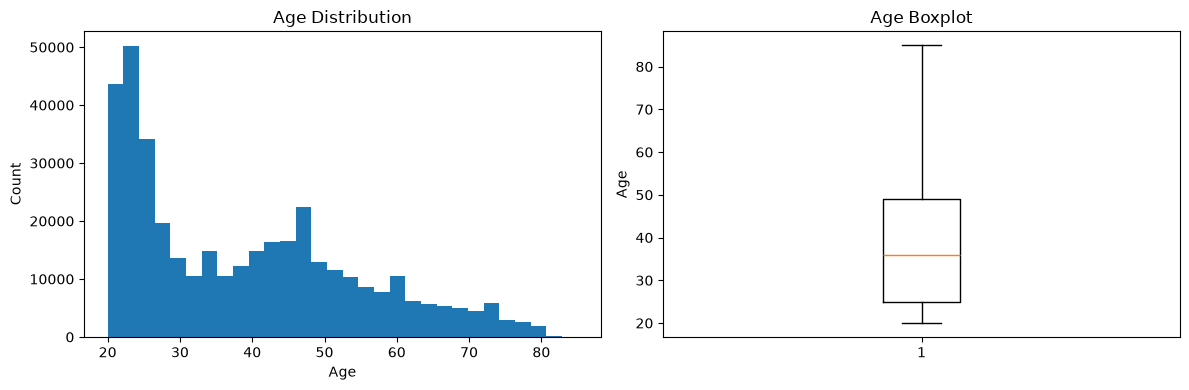

/var/folders/bb/9wscb13j3ml205njxw9_qtmh0000gn/T/ipykernel_12907/3934928395.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[col], vert=True)


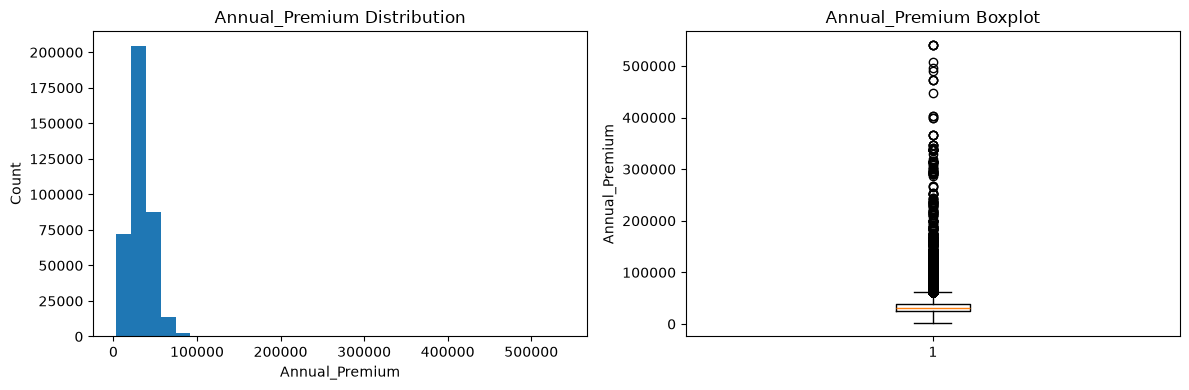

/var/folders/bb/9wscb13j3ml205njxw9_qtmh0000gn/T/ipykernel_12907/3934928395.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[col], vert=True)


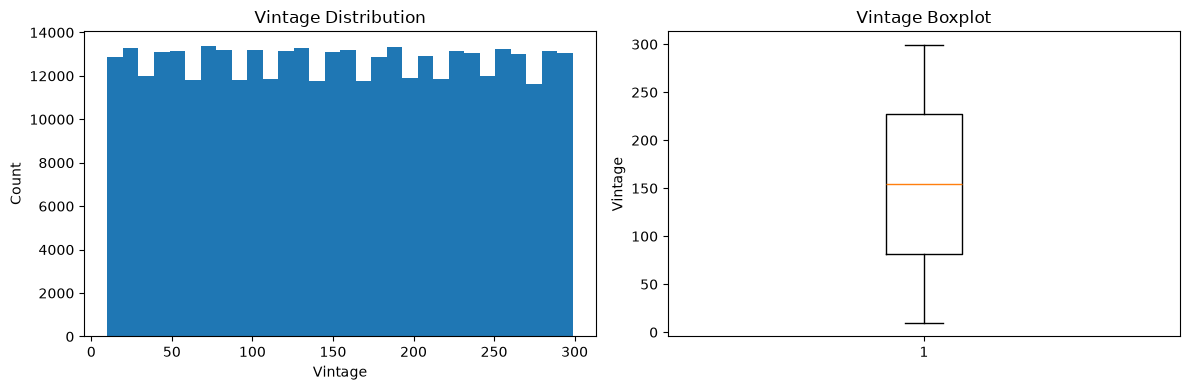

In [10]:
continuous_cols = [
    "Age",
    "Annual_Premium",
    "Vintage"
]

import matplotlib.pyplot as plt

for col in continuous_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    ax[0].hist(df[col], bins=30)
    ax[0].set_title(f"{col} Distribution")
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Count")

    # Boxplot
    ax[1].boxplot(df[col], vert=True)
    ax[1].set_title(f"{col} Boxplot")
    ax[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

In [11]:
vehicle_order = [
    "< 1 Year",
    "1-2 Year",
    "> 2 Years"
]

df["Vehicle_Age"] = pd.Categorical(
    df["Vehicle_Age"],
    categories=vehicle_order,
    ordered=True
)

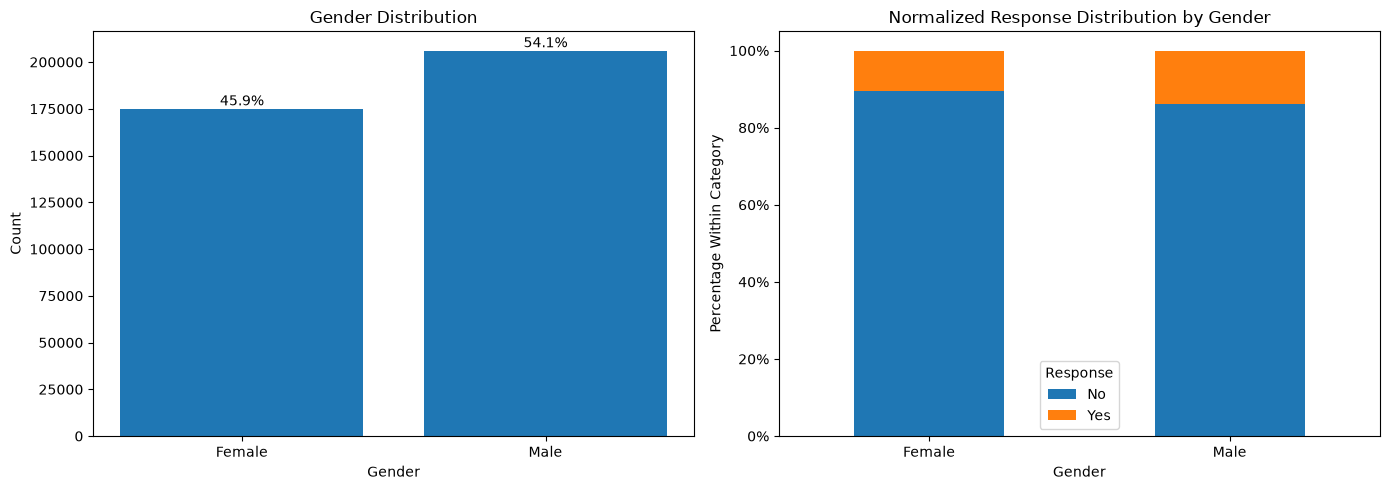

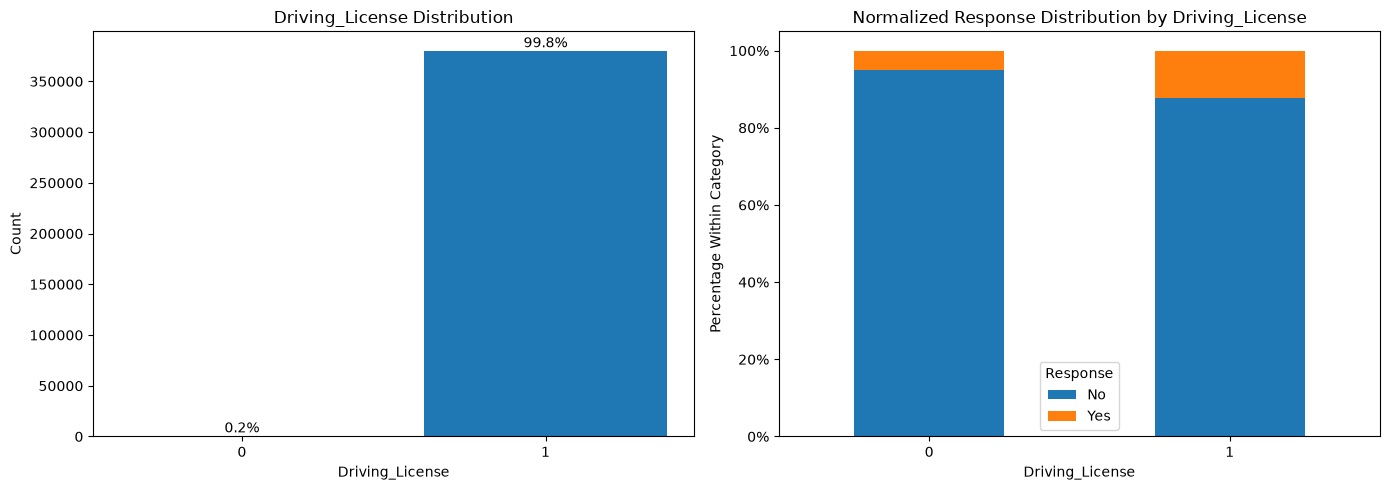

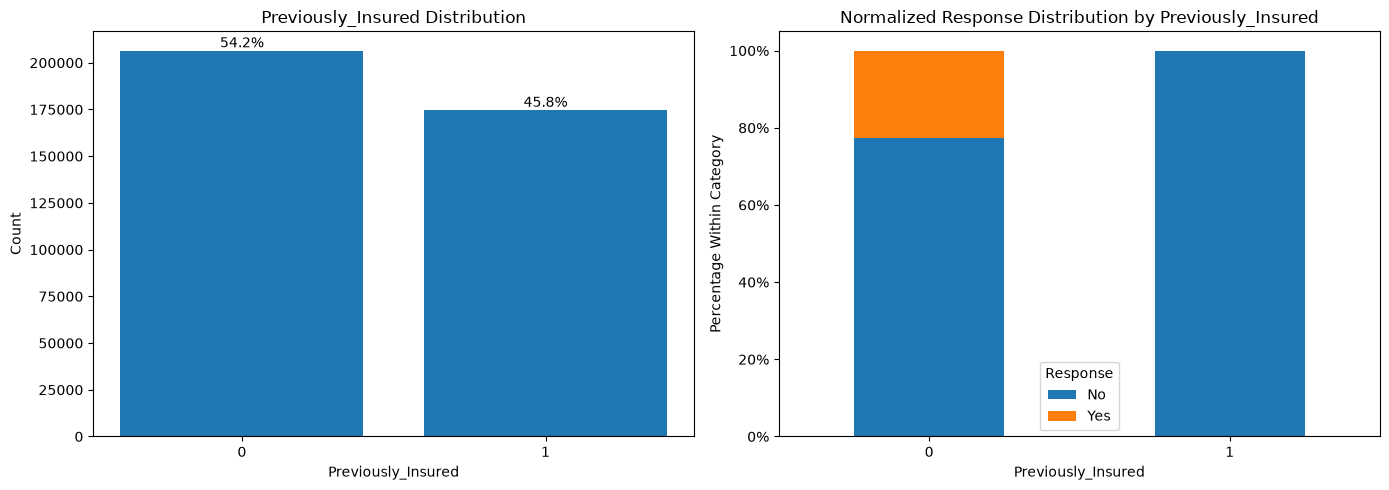

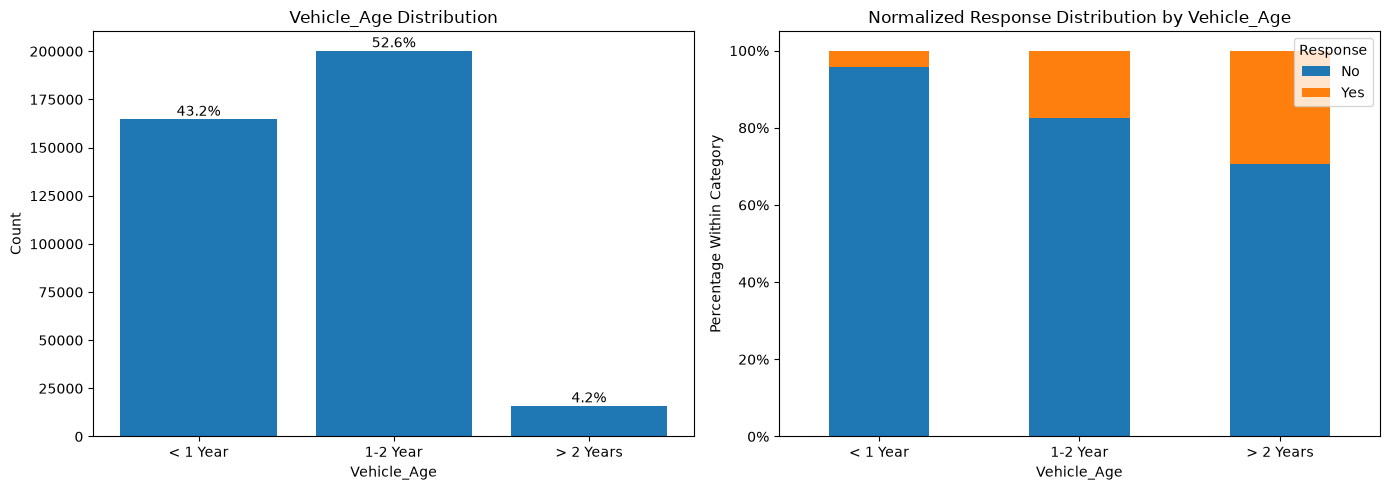

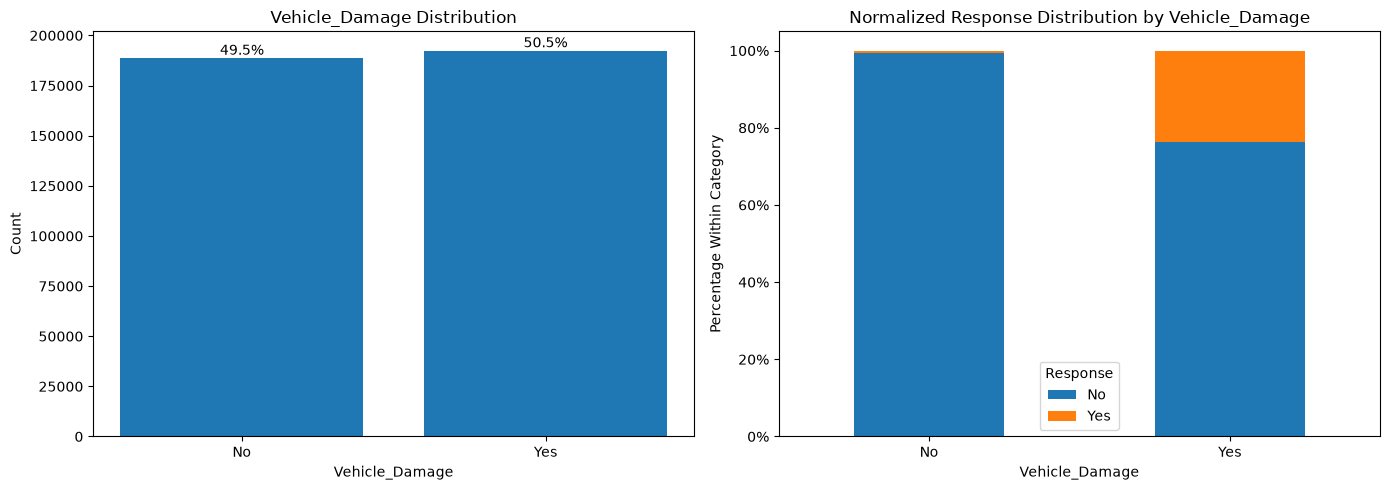

In [12]:
from matplotlib.ticker import PercentFormatter

small_categorical = [
    "Gender",
    "Driving_License",
    "Previously_Insured",
    "Vehicle_Age",
    "Vehicle_Damage"
]

for col in small_categorical:

    # Overall category distribution
    counts = df[col].value_counts().sort_index()
    percentages = counts / len(df)

    # Response distribution within each category
    response_dist = pd.crosstab(
        df[col],
        df["Response"],
        normalize="index"
    ).sort_index()

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(14, 5)
    )

    # -----------------------------
    # Left: overall distribution
    # -----------------------------
    bars = axes[0].bar(
        counts.index.astype(str),
        counts.values
    )

    axes[0].set_title(f"{col} Distribution")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    for bar, pct in zip(bars, percentages):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1%}",
            ha="center",
            va="bottom"
        )

    # -----------------------------
    # Right: normalized response
    # -----------------------------
    response_dist.plot(
        kind="bar",
        stacked=True,
        ax=axes[1]
    )

    axes[1].set_title(f"Normalized Response Distribution by {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Percentage Within Category")
    axes[1].yaxis.set_major_formatter(PercentFormatter(1))
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend(
        title="Response",
        labels=["No", "Yes"]
    )

    plt.tight_layout()
    plt.show()

In [13]:
dl_counts = pd.crosstab(
    df["Driving_License"],
    df["Response"]
)

dl_counts.index = ["No", "Yes"]
dl_counts.columns = ["No", "Yes"]
dl_counts.index.name = "Driving License"
dl_counts.columns.name = "Response"

print("Contingency Table: Driving License vs. Response")
display(dl_counts)

dl_props = pd.crosstab(
    df["Driving_License"],
    df["Response"],
    normalize="index"
)

dl_props.index = ["No", "Yes"]
dl_props.columns = ["No", "Yes"]
dl_props.index.name = "Driving License"
dl_props.columns.name = "Response"

print("Row-Normalized Proportions: Driving License vs. Response")
display(dl_props.style.format("{:.2%}"))

Contingency Table: Driving License vs. Response


Response,No,Yes
Driving License,,
No,771,41
Yes,333628,46669


Row-Normalized Proportions: Driving License vs. Response


Response,No,Yes
Driving License,,
No,94.95%,5.05%
Yes,87.73%,12.27%


In [36]:
region_counts = (
    df["Region_Code"]
    .value_counts()
    .sort_values(ascending=False)
)

region_counts.describe()

count        53.000000
mean       7190.735849
std       15065.666022
min         183.000000
25%        1960.000000
50%        3198.000000
75%        6942.000000
max      106415.000000
Name: count, dtype: float64

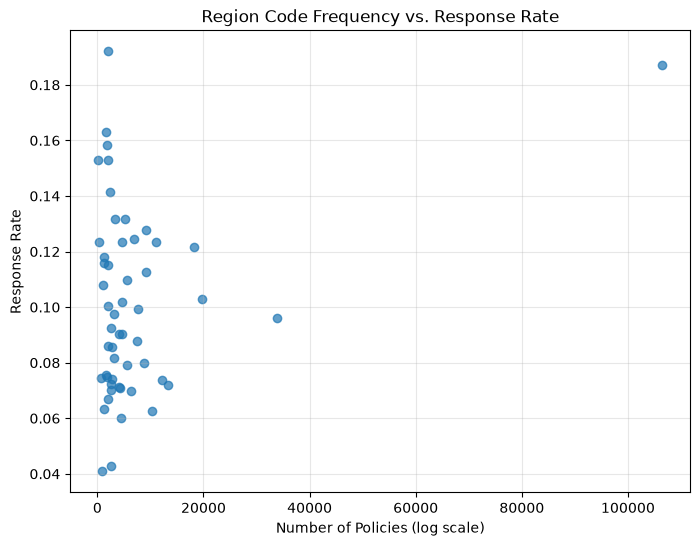

In [35]:
region_summary = (
    df.groupby("Region_Code")
      .agg(
          Count=("Response", "size"),
          ResponseRate=("Response", "mean")
      )
      .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    region_summary["Count"],
    region_summary["ResponseRate"],
    alpha=0.7
)

   # Important because counts span ~200 to 106,000

plt.xlabel("Number of Policies (log scale)")
plt.ylabel("Response Rate")
plt.title("Region Code Frequency vs. Response Rate")

plt.grid(alpha=0.3)

plt.show()

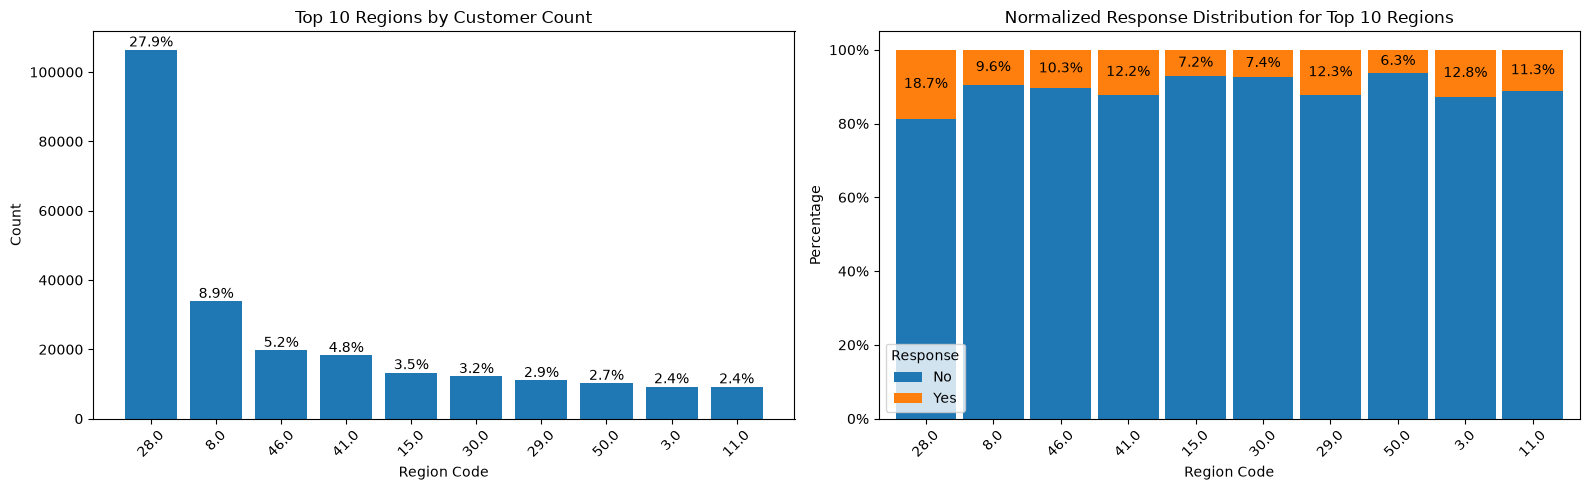

In [39]:
top_n = 10

region_counts = (
    df["Region_Code"]
      .value_counts()
      .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -----------------------------
# Left: Top regions by frequency
# -----------------------------
left_bars = axes[0].bar(
    region_counts.index.astype(str),
    region_counts.values
)

axes[0].set_title(f"Top {top_n} Regions by Customer Count")
axes[0].set_xlabel("Region Code")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Percentage of the entire dataset represented by each region
region_percentages = region_counts / len(df)

for bar, pct in zip(left_bars, region_percentages):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1%}",
        ha="center",
        va="bottom"
    )

# -----------------------------
# Right: Normalized response distribution
# -----------------------------
region_response = (
    pd.crosstab(
        df["Region_Code"],
        df["Response"],
        normalize="index"
    )
    .loc[region_counts.index]
    .reindex(columns=[0, 1], fill_value=0)
)

region_response.plot(
    kind="bar",
    stacked=True,
    width=0.9,
    ax=axes[1]
)

axes[1].set_title(
    f"Normalized Response Distribution for Top {top_n} Regions"
)
axes[1].set_xlabel("Region Code")
axes[1].set_ylabel("Percentage")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(
    title="Response",
    labels=["No", "Yes"]
)

# Place each Yes percentage in the center of the orange segment
for i, rate in enumerate(region_response[1]):
    axes[1].text(
        i,
        1 - rate / 2,
        f"{rate:.1%}",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.show()

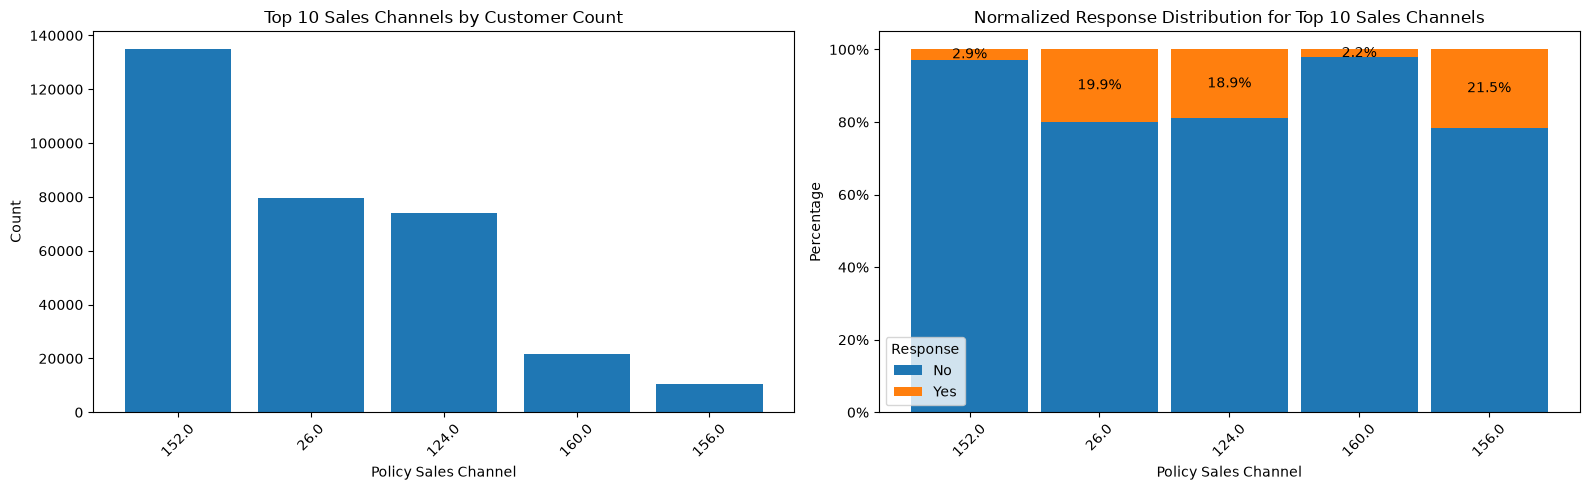

In [38]:
top_n = 10

channel_counts = df["Policy_Sales_Channel"].value_counts().head(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -----------------------------
# Left: Top regions by frequency
# -----------------------------
axes[0].bar(
    channel_counts.index.astype(str),
    channel_counts.values
)

axes[0].set_title(f"Top {top_n} Sales Channels by Customer Count")
axes[0].set_xlabel("Policy Sales Channel")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# -----------------------------
# Right: Response rate
# -----------------------------
channel_response = (
    pd.crosstab(
        df["Policy_Sales_Channel"],
        df["Response"],
        normalize="index"
    )
    .loc[channel_counts.index]
)

channel_response.plot(
    kind="bar",
    stacked=True,
    width=0.9,
    ax=axes[1]
)

axes[1].set_title(
    f"Normalized Response Distribution for Top {top_n} Sales Channels"
)
axes[1].set_xlabel("Policy Sales Channel")
axes[1].set_ylabel("Percentage")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(
    title="Response",
    labels=["No", "Yes"]
)

for i, rate in enumerate(channel_response[1]):
    axes[1].text(
        i,
        1 - rate / 2,
        f"{rate:.1%}",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
channel_counts = df["Policy_Sales_Channel"].value_counts()

channel_counts.describe()

count       155.000000
mean       2458.767742
std       13928.481161
min           1.000000
25%           8.500000
50%          51.000000
75%         243.000000
max      134784.000000
Name: count, dtype: float64

In [57]:
channel_counts = df["Policy_Sales_Channel"].value_counts()

channel_summary = pd.DataFrame({
    "Count": channel_counts,
    "Share": channel_counts / channel_counts.sum()
})

channel_summary["Cumulative_Coverage"] = (
    channel_summary["Share"].cumsum()
)

channel_summary.head(20)



,Count,Share,Cumulative_Coverage
Policy_Sales_Channel,,,
152.0,134784,0.353663,0.353663
26.0,79700,0.209127,0.562789
124.0,73995,0.194157,0.756946
160.0,21779,0.057146,0.814093
156.0,10661,0.027974,0.842066
122.0,9930,0.026056,0.868122
157.0,6684,0.017538,0.885660
154.0,5993,0.015725,0.901385
151.0,3885,0.010194,0.911579


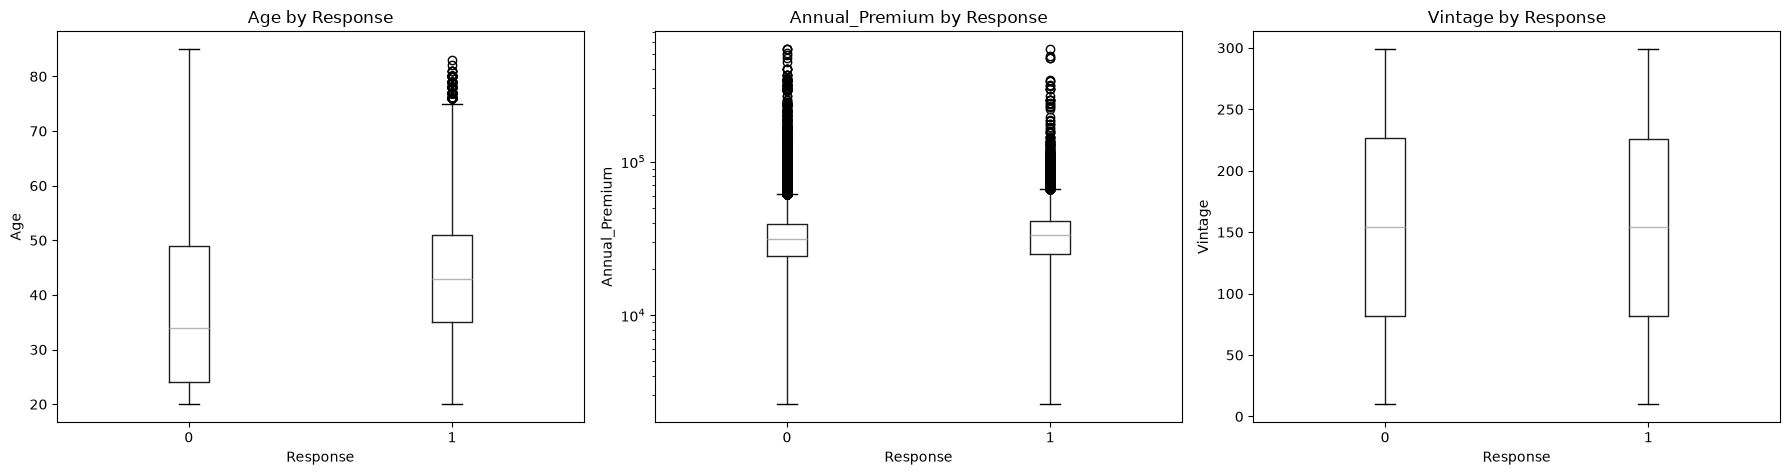

In [16]:
numeric_cols = ["Age", "Annual_Premium", "Vintage"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numeric_cols):
    df.boxplot(
        column=col,
        by="Response",
        ax=ax,
        grid=False
    )

    ax.set_title(f"{col} by Response")
    ax.set_xlabel("Response")
    ax.set_ylabel(col)

axes[1].set_yscale("log")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
import 

sns.lineplot(
    x="Vintage",
    y="Response"
)



In [17]:
numeric_cols = [
    "Age",
    "Annual_Premium",
    "Vintage",
    "Response"
]

correlation_matrix = df[numeric_cols].corr()

display(correlation_matrix)

,Age,Annual_Premium,Vintage,Response
Age,1.000000,0.067507,-0.001264,0.111147
Annual_Premium,0.067507,1.000000,-0.000608,0.022575
Vintage,-0.001264,-0.000608,1.000000,-0.001050
Response,0.111147,0.022575,-0.001050,1.000000


In [18]:
response_counts = df["Response"].value_counts()
response_proportions = df["Response"].value_counts(normalize=True)

display(
    pd.DataFrame({
        "Count": response_counts,
        "Proportion": response_proportions
    })
)

,Count,Proportion
Response,,
0,334399,0.877437
1,46710,0.122563
